In [1]:
import numpy as np
import torch
import torch.nn.functional
from e3nn import o3
from matplotlib import pyplot as plt
%matplotlib inline

from mace import data, modules, tools
from mace.tools import torch_geometric

/raid/m.tolloso/miniconda3/envs/mace/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = torch.l

In [2]:
from ase.io import read, write
import numpy as np
from matplotlib import pyplot as plt


## Energy and forces with xtb

cos'è molID?

In [ ]:
import os
os.makedirs("MACE_tests/mace01/", exist_ok=True)

from mace.cli.eval_configs import main as mace_eval_configs_main
import sys

# os.mkdir("/raid/m.tolloso/mace/outputs/eval", exist=True)

def eval_mace(configs, model, output):
	sys.argv = ["program", "--configs", configs, "--model", model, "--output", output, "--device", "cuda"]
	mace_eval_configs_main()
	
#evaluate the training set
eval_mace(configs="/raid/m.tolloso/mace/dataset/ani1x-processed/train.xyz",
		  model="outputs/checkpoints/mace-mv_run-0.model outputs/checkpoints/mace-mv_run-1.model outputs/checkpoints/mace-mv_run-2.model",
		  output="/raid/m.tolloso/mace/outputs/eval/mace-mv-train.xyz")

#evaluate the test set
eval_mace(configs="/raid/m.tolloso/mace/dataset/ani1x-processed/test.xyz",
		  model="outputs/checkpoints/mace-mv_run-0.model,outputs/checkpoints/mace-mv_run-1.model,outputs/checkpoints/mace-mv_run-2.model",
		  output="/raid/m.tolloso/mace/outputs/eval/mace-mv-test.xyz")

/raid/m.tolloso/mace/mace/cli/eval_configs.py:316: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m = torch.load(f=p, map_location=args.device)
/raid/m.tolloso/mace/mace/cli/

### cosa cambia tra i vari models e checkpoint?

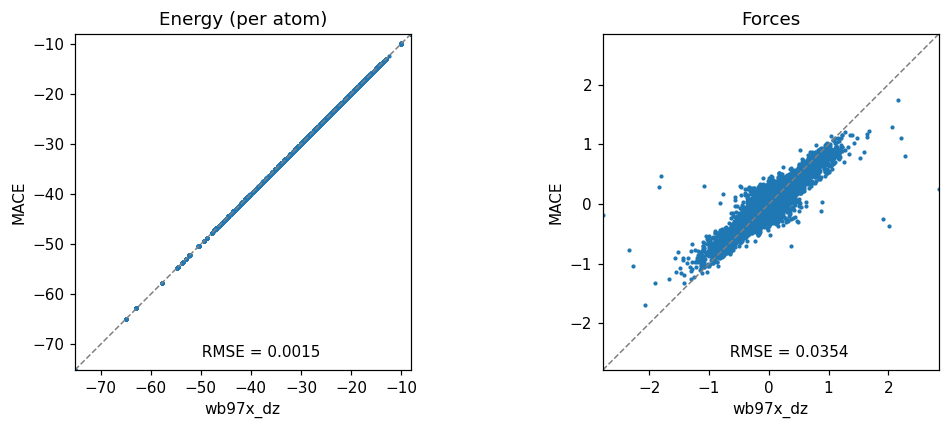

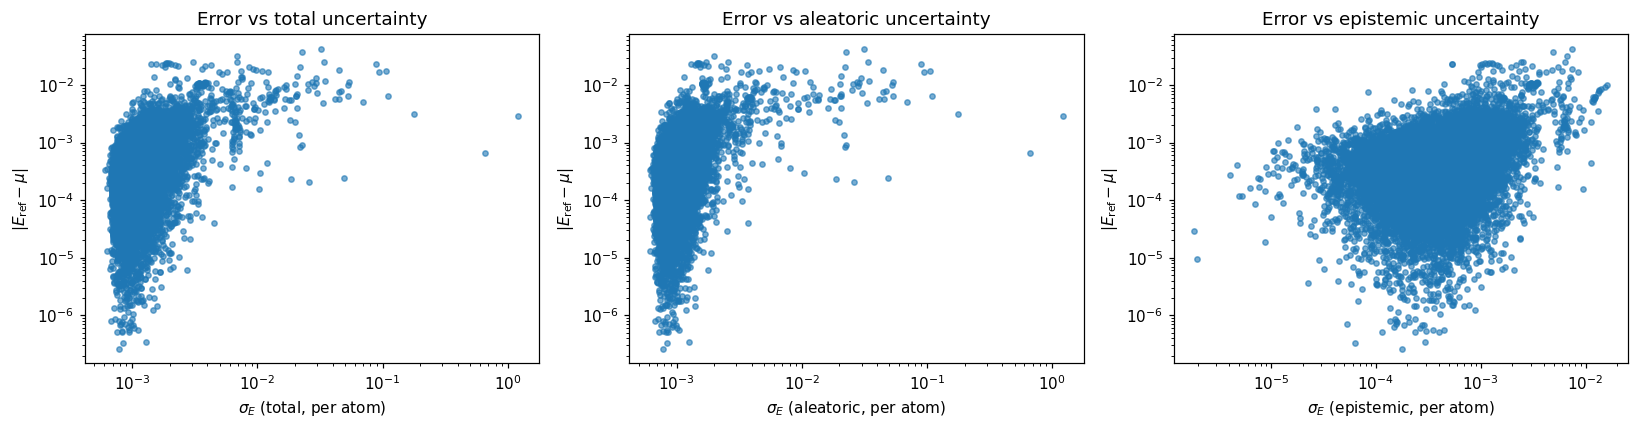

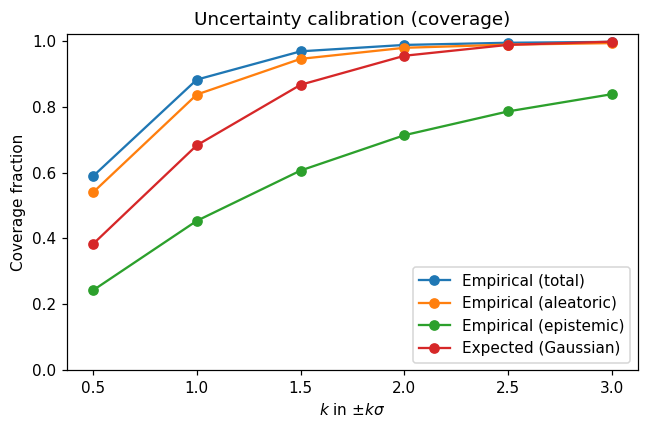

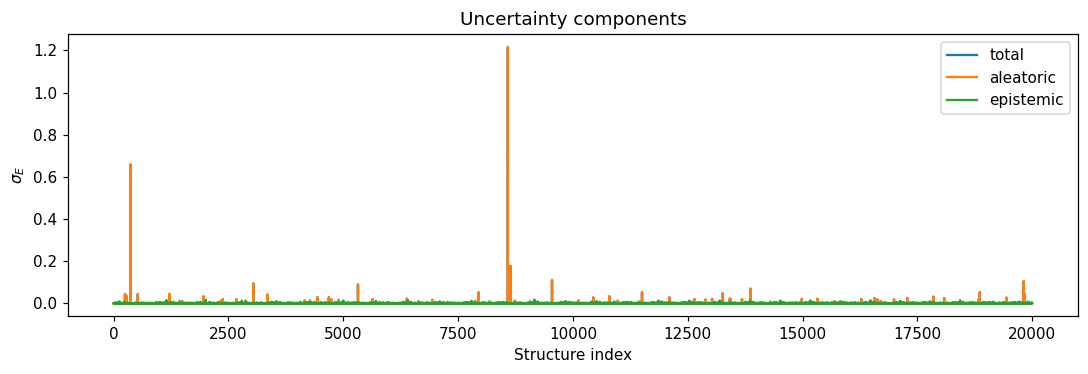

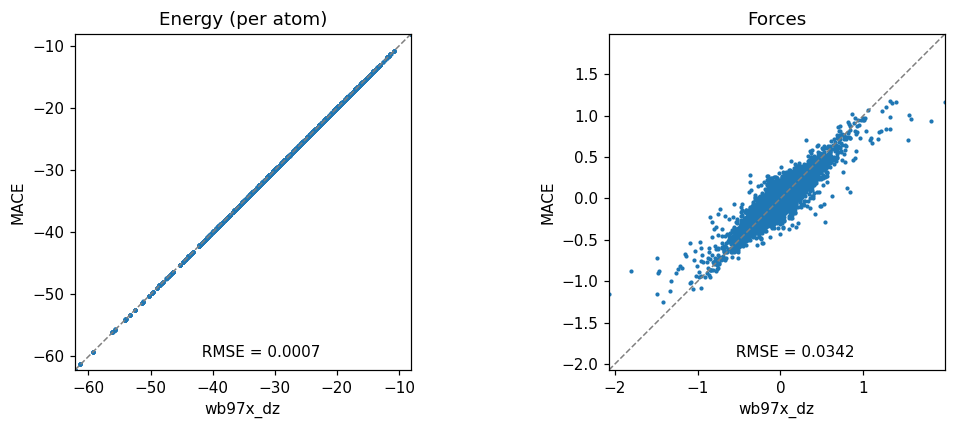

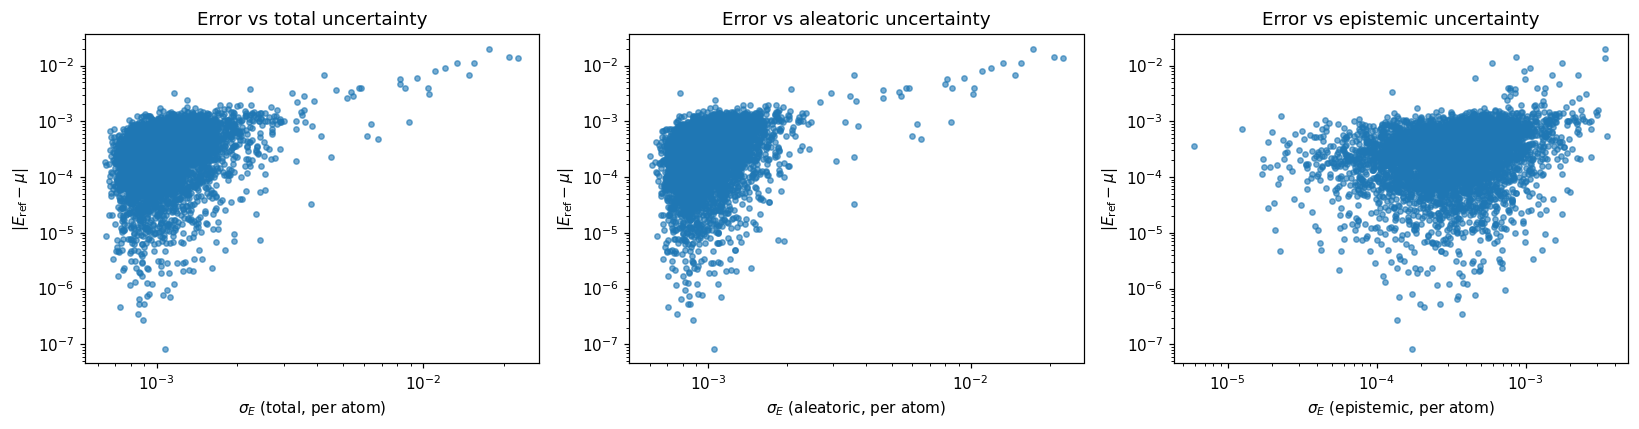

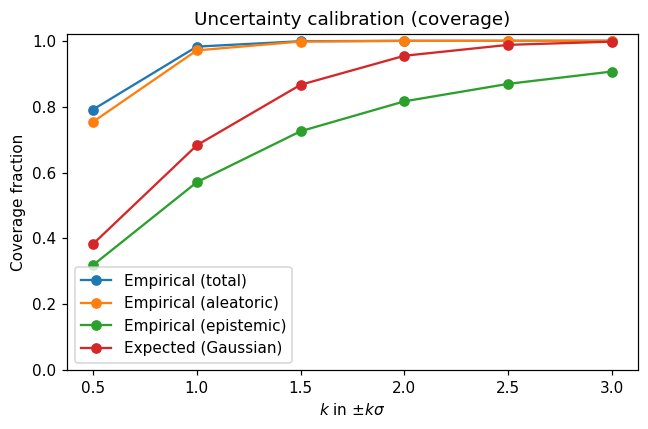

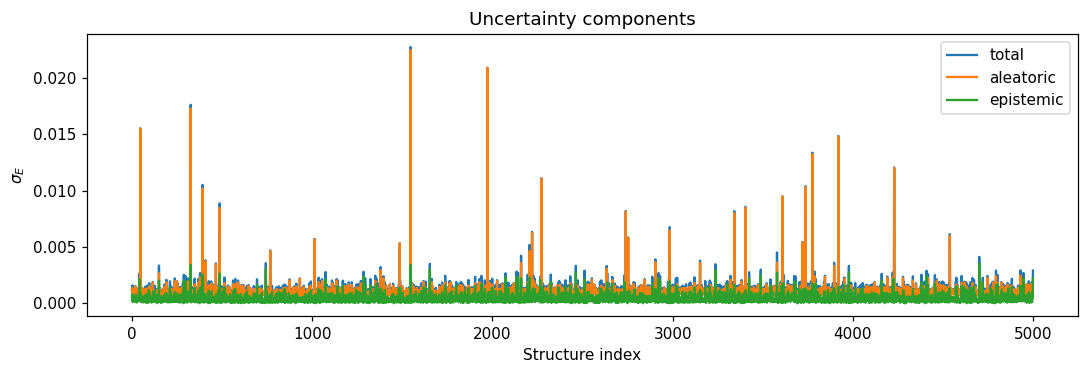

In [2]:
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt
from aseMolec import pltProps as pp
from aseMolec import extAtoms as ea

# -----------------------
# Helpers to extract keys
# -----------------------

def get_info_array(db, key):
	"""Return shape [n_structures] float array from atoms.info[key]."""
	return np.array([float(at.info[key]) for at in db], dtype=float)

def get_forces_concat(db, key):
	"""Return flattened forces concatenated over structures: shape [sum_i (3*Ni)]."""
	return np.concatenate([at.arrays[key].reshape(-1) for at in db], axis=0)

def get_natoms(db):
	return np.array([len(at) for at in db], dtype=int)

def have_info_key(db, key):
	return all(key in at.info for at in db)

# -----------------------
# Main plotting function
# -----------------------

def plot_stats_with_uncertainty(
	db,
	labs=("wb97x_dz", "MACE"),
	ref_energy_key="wb97x_dz.energy",
	ref_forces_key="wb97x_dz.forces",
	pred_energy_key="MACE_energy",
	pred_forces_key="MACE_forces",
	# Ensemble/MVE keys:
	total_std_key="MACE_energy_std",
	ale_std_key="MACE_energy_aleatoric_std",
	epi_std_key="MACE_energy_epistemic_std",
	per_atom=True,
	eps=1e-12,
):
	"""
	Plots:
	  Figure 1: parity plots (energy, forces)
	  Figure 2: abs error vs sigma for (total, aleatoric, epistemic) if available
	  Figure 3: coverage curves for (total, aleatoric, epistemic) if available
	  Figure 4: timeseries-like (index) of std components if available
	"""

	# --- Energies ---
	e_ref = get_info_array(db, ref_energy_key)
	e_pred = get_info_array(db, pred_energy_key)

	nat = get_natoms(db)
	if per_atom:
		e_ref_plot = e_ref / nat
		e_pred_plot = e_pred / nat
		energy_title = r"Energy (per atom)"
		std_unit = "per atom"
	else:
		e_ref_plot = e_ref
		e_pred_plot = e_pred
		energy_title = r"Energy (total)"
		std_unit = "total"

	abs_err = np.abs(e_ref_plot - e_pred_plot)

	# --- Forces ---
	# If you trained without forces, these keys might not exist: keep it safe.
	have_forces = (ref_forces_key in db[0].arrays) and (pred_forces_key in db[0].arrays)
	if have_forces:
		f_ref = get_forces_concat(db, ref_forces_key)
		f_pred = get_forces_concat(db, pred_forces_key)

	# --- Uncertainty availability ---
	have_total = have_info_key(db, total_std_key)
	have_ale = have_info_key(db, ale_std_key)
	have_epi = have_info_key(db, epi_std_key)

	# Collect sigmas (and normalize per-atom if requested)
	sigmas = {}
	if have_total:
		s = get_info_array(db, total_std_key)
		sigmas["total"] = (s / nat) if per_atom else s
	if have_ale:
		s = get_info_array(db, ale_std_key)
		sigmas["aleatoric"] = (s / nat) if per_atom else s
	if have_epi:
		s = get_info_array(db, epi_std_key)
		sigmas["epistemic"] = (s / nat) if per_atom else s

	# -----------------------
	# Figure 1: parity plots
	# -----------------------
	plt.figure(figsize=(10, 4), dpi=110)

	plt.subplot(1, 2, 1)
	pp.plot_prop(
		e_ref_plot.flatten(),
		e_pred_plot.flatten(),
		title=energy_title,
		labs=list(labs),
		rel=False,
	)

	plt.subplot(1, 2, 2)
	if have_forces:
		pp.plot_prop(
			f_ref.flatten(),
			f_pred.flatten(),
			title=r"Forces",
			labs=list(labs),
			rel=False,
		)
	else:
		plt.axis("off")
		plt.text(0.5, 0.5, "Forces not available in this XYZ", ha="center", va="center")

	plt.tight_layout()

	if len(sigmas) == 0:
		print("[info] No uncertainty std keys found → skipping uncertainty plots.")
		return
	# ------------------------------------
	# Figure 2: abs error vs sigma (3 panels max) - log-log scale
	# ------------------------------------
	keys_order = [k for k in ["total", "aleatoric", "epistemic"] if k in sigmas]
	n_panels = len(keys_order)
	plt.figure(figsize=(5 * n_panels, 4), dpi=110)

	for j, k in enumerate(keys_order, start=1):
		sigma_plot = np.maximum(sigmas[k], eps)
		err_plot = np.maximum(abs_err, eps)

		plt.subplot(1, n_panels, j)
		plt.scatter(sigma_plot, err_plot, s=12, alpha=0.6)
		plt.xscale("log")
		plt.yscale("log")
		plt.xlabel(rf"$\sigma_E$ ({k}, {std_unit})")
		plt.ylabel(r"$|E_{\rm ref}-\mu|$")
		plt.title(f"Error vs {k} uncertainty")

	plt.tight_layout()

	# ------------------------------------
	# Figure 3: coverage curves
	# ------------------------------------
	from math import erf, sqrt
	ks = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0])
	expected = np.array([erf(float(k) / sqrt(2.0)) for k in ks])

	plt.figure(figsize=(6, 4), dpi=110)
	for k in keys_order:
		sigma_plot = np.maximum(sigmas[k], eps)
		z = abs_err / sigma_plot
		empirical = np.array([(z <= kk).mean() for kk in ks])
		plt.plot(ks, empirical, marker="o", label=f"Empirical ({k})")

	plt.plot(ks, expected, marker="o", label="Expected (Gaussian)")
	plt.xlabel(r"$k$ in $\pm k\sigma$")
	plt.ylabel("Coverage fraction")
	plt.ylim(0, 1.02)
	plt.title("Uncertainty calibration (coverage)")
	plt.legend()
	plt.tight_layout()

	# ------------------------------------
	# Figure 4: quick “timeseries” of std components
	# ------------------------------------
	plt.figure(figsize=(10, 3.5), dpi=110)
	x = np.arange(len(db))
	for k in keys_order:
		plt.plot(x, sigmas[k], label=k)
	plt.xlabel("Structure index")
	plt.ylabel(r"$\sigma_E$")
	plt.title("Uncertainty components")
	plt.legend()
	plt.tight_layout()


# -----------------------
# Run
# -----------------------

train_data = read("/raid/m.tolloso/mace/outputs/eval/mace-mv-train.xyz", ":")
test_data  = read("/raid/m.tolloso/mace/outputs/eval/mace-mv-test.xyz", ":")

plot_stats_with_uncertainty(
	train_data,
	labs=("wb97x_dz", "MACE"),
	ref_energy_key="wb97x_dz.energy",
	ref_forces_key="wb97x_dz.forces",
	pred_energy_key="MACE_energy",
	pred_forces_key="MACE_forces",
	total_std_key="MACE_energy_std",
	ale_std_key="MACE_energy_aleatoric_std",
	epi_std_key="MACE_energy_epistemic_std",
	per_atom=True,
)

plot_stats_with_uncertainty(
	test_data,
	labs=("wb97x_dz", "MACE"),
	ref_energy_key="wb97x_dz.energy",
	ref_forces_key="wb97x_dz.forces",
	pred_energy_key="MACE_energy",
	pred_forces_key="MACE_forces",
	total_std_key="MACE_energy_std",
	ale_std_key="MACE_energy_aleatoric_std",
	epi_std_key="MACE_energy_epistemic_std",
	per_atom=True,
)


/raid/m.tolloso/miniconda3/envs/mace/lib/python3.11/site-packages/ase/ga/__init__.py:25: FutureWarning: The ase.ga code has moved to a separate project, ase_ga:
https://github.com/dtu-energy/ase-ga .
Please install it using e.g. pip install ase-ga.
Please import from ase_ga what would previously be imported from ase.ga.
ase.ga placeholders will be removed in a future release.

  warnings.warn(msg, FutureWarning)


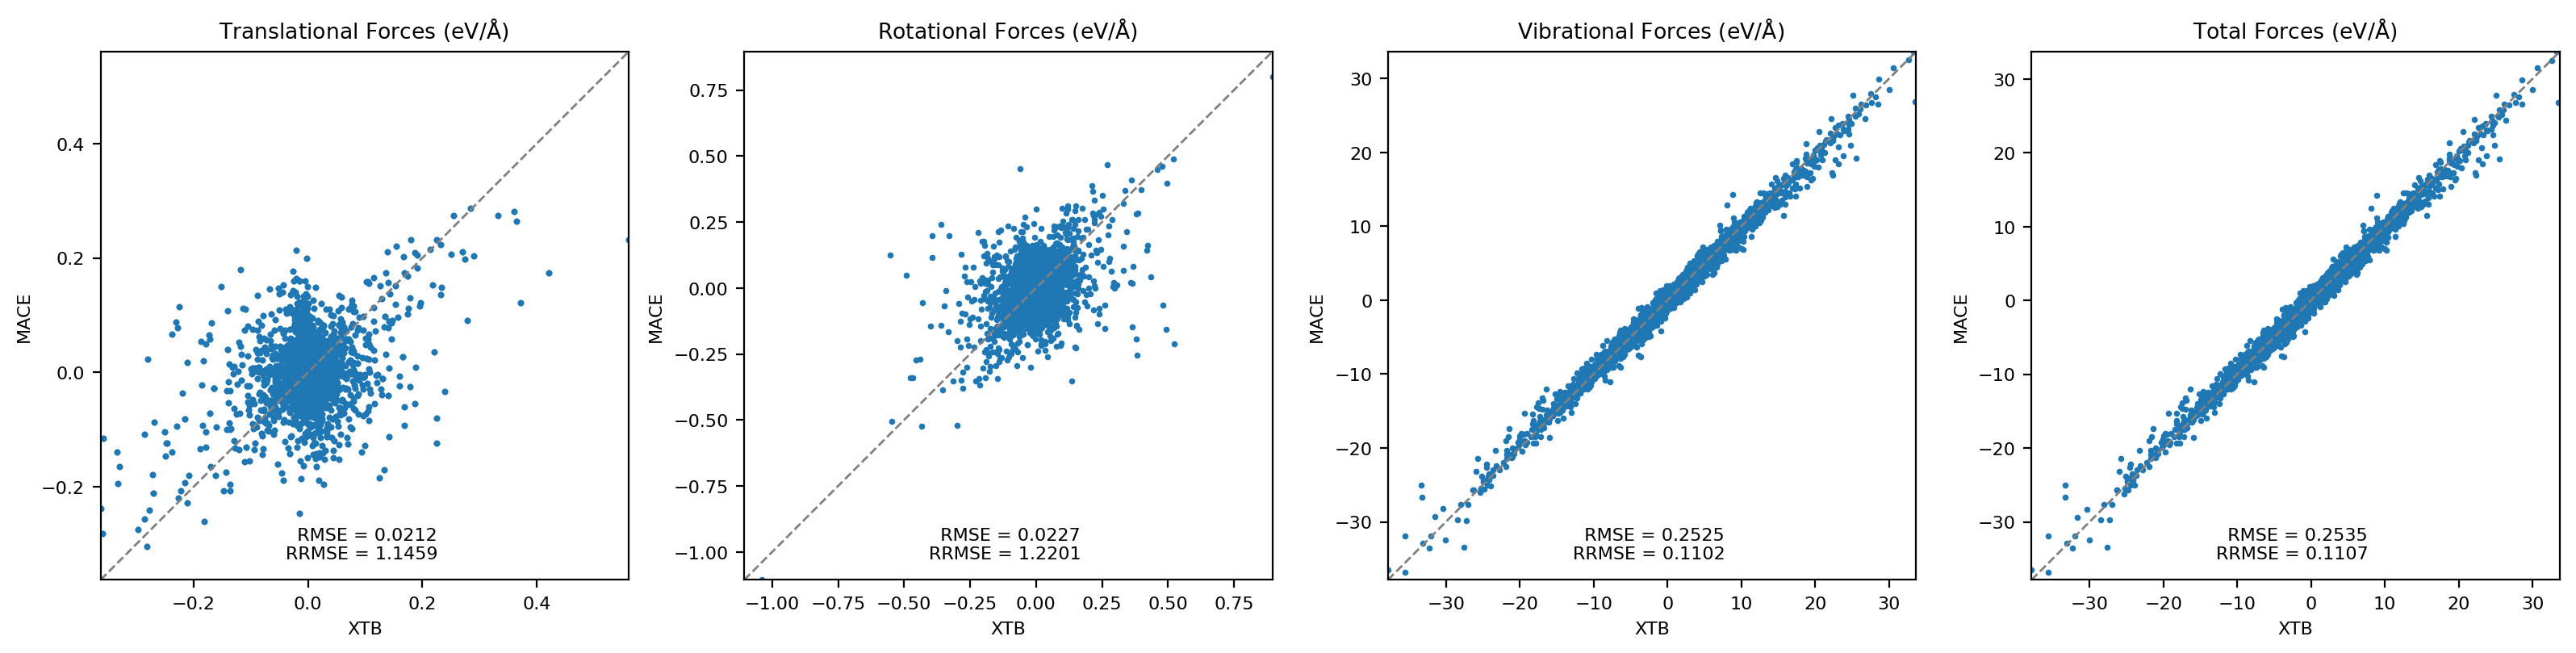

In [5]:
from aseMolec import pltProps as pp
from aseMolec import anaAtoms as aa
from aseMolec import extAtoms as ea


db1 = read('MACE_tests/mace01/solvent_test.xyz', ':')
ea.rename_prop_tag(db1, 'energy_xtb', 'energy') #Backward compatibility
ea.rename_prop_tag(db1, 'forces_xtb', 'forces') #Backward compatibility

db2 = read('MACE_tests/mace01/solvent_test.xyz', ':')
ea.rename_prop_tag(db2, 'MACE_energy', 'energy') #Backward compatibility
ea.rename_prop_tag(db2, 'MACE_forces', 'forces') #Backward compatibility

aa.extract_molecs(db1, intra_inter=True)
aa.extract_molecs(db2, intra_inter=True)

pp.plot_trans_rot_vib(db1, db2, labs=['XTB', 'MACE'])

In [6]:
train_data[0].info

{'config_type': 'IsolatedAtom',
 'energy_xtb': np.float64(-10.707211383396714),
 'energy_mace': np.float64(-10.707211383396714),
 'energy_mace_logvar': np.float64(1.5563962095364836),
 'energy_mace_var': np.float64(4.741702315562017),
 'energy_mace_std': np.float64(2.177545020329549)}

In [ ]:
import numpy as np

def get_pred_energy_and_sigma(db, prefix="MACE_"):
	"""
	Returns:
	  mu: shape [n_structures]
	  sigma: shape [n_structures] or None if not present
	"""
	mu = np.array([at.info[prefix + "energy_mace"] for at in db], dtype=float)

	# Preferred: std
	if all((prefix + "energy_mace_std") in at.info for at in db):
		sigma = np.array([at.info[prefix + "energy_mace_std"] for at in db], dtype=float)
		return mu, sigma

	# Fallback: var
	if all((prefix + "energy_mace_var") in at.info for at in db):
		var = np.array([at.info[prefix + "energy_mace_var"] for at in db], dtype=float)
		sigma = np.sqrt(np.clip(var, 0.0, None))
		return mu, sigma

	# Fallback: logvar
	if all((prefix + "energy_mace_logvar") in at.info for at in db):
		logvar = np.array([at.info[prefix + "energy_mace_logvar"] for at in db], dtype=float)
		sigma = np.sqrt(np.exp(logvar))
		return mu, sigma

	return mu, None

import matplotlib.pyplot as plt

def plot_error_vs_sigma(db, labs, prefix="MACE_"):
	# y_true: XTB energy (your current usage)
	y_true = np.array([at.info["wb97x_dz.energy"] for at in db], dtype=float)

	# y_pred: MACE mean + sigma
	y_pred, sigma = get_pred_energy_and_sigma(db, prefix=prefix)
	if sigma is None:
		print("No uncertainty found in Atoms.info; cannot plot error vs sigma.")
		return

	err = np.abs(y_true - y_pred)

	# Compute correlation coefficient
	corr = np.corrcoef(sigma, err)[0, 1]

	plt.figure(figsize=(6,5), dpi=100)
	plt.scatter(sigma, err, s=12, alpha=0.6)
	# Plot bisector (y=x)
	# xlim = plt.xlim()
	# ylim = plt.ylim()
	# min_lim = min(xlim[0], ylim[0])
	# max_lim = max(xlim[1], ylim[1])
	# plt.plot([min_lim, max_lim], [min_lim, max_lim], 'r--', label='y = x')
	# plt.xlim(xlim)
	# plt.ylim(ylim)
	plt.xlabel(r"Predicted $\sigma_E$ (eV)")
	plt.ylabel(r"Absolute error $|E_{\rm ref}-\mu|$ (eV)")
	plt.title("Energy error vs predicted uncertainty")
	plt.legend()
	# Annotate correlation
	plt.text(0.05, 0.95, f"corr = {corr:.2f}", transform=plt.gca().transAxes,
			 fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round", fc="w", ec="0.5"))
	plt.tight_layout()

def plot_coverage(db, prefix="MACE_", ks=(0.5, 1.0, 1.5, 2.0, 2.5, 3.0)):
	y_true = np.array([at.info["wb97x_dz.energy"] for at in db], dtype=float)
	y_pred, sigma = get_pred_energy_and_sigma(db, prefix=prefix)
	if sigma is None:
		print("No uncertainty found in Atoms.info; cannot plot coverage.")
		return

	# Avoid division issues
	sigma = np.maximum(sigma, 1e-12)

	z = np.abs(y_true - y_pred) / sigma  # standardized absolute error

	empirical = np.array([(z <= k).mean() for k in ks])

	# Expected coverage for N(0,1): P(|Z|<=k) = erf(k/sqrt(2))
	from math import erf, sqrt
	expected = np.array([erf(k / sqrt(2.0)) for k in ks])

	plt.figure(figsize=(6,5), dpi=100)
	plt.plot(ks, empirical, marker="o", label="Empirical")
	plt.plot(ks, expected, marker="o", label="Expected (Gaussian)")
	plt.xlabel(r"$k$ in $\pm k\sigma$")
	plt.ylabel("Coverage fraction")
	plt.ylim(0, 1.02)
	plt.title("Uncertainty calibration (coverage)")
	plt.legend()
	plt.tight_layout()


In [6]:
print(train_data[3].info)

{'Nmols': np.int64(3), 'Comp': 'VC(3)', 'energy_xtb': np.float64(-1602.093208085042), 'energy_mace': np.float64(-1600.56544657206), 'energy_mace_logvar': np.float64(7.776392706681044), 'energy_mace_var': np.float64(2383.6607296772995), 'energy_mace_std': np.float64(48.8227480758437)}


/tmp/ipykernel_3474895/2834301870.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


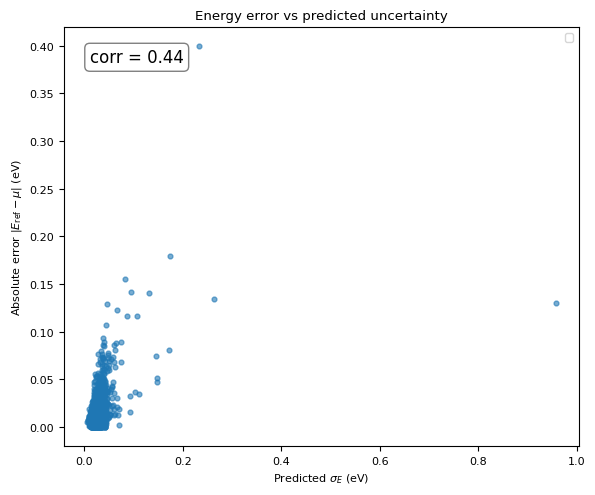

In [14]:
# plot_RMSEs(train_data, labs=['XTB', 'MACE'])
# plot_error_vs_sigma(train_data, labs=['XTB', 'MACE'], prefix="")
# plot_coverage(train_data, prefix="")

# plot_RMSEs(test_data, labs=['XTB', 'MACE'])
plot_error_vs_sigma(test_data, labs=['wb97x_dz.energy', 'MACE'], prefix="")
# plot_coverage(test_data, prefix="")
# Optional:
# plot_energy_parity_with_errorbars(test_data, labs=['XTB', 'MACE'], prefix="MACE_")
